In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.csv to Dataset.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Dataset.csv')
df.head()

,Scenario,Requirement,Requirement Type,Author
0,The Internet of Objects (IoT) Based Applicatio...,Collection and analysis of environmental data ...,Functional,Human
1,The Internet of Objects (IoT) Based Applicatio...,"Monitoring, analyzing traffic flow and providi...",Functional,Human
2,The Internet of Objects (IoT) Based Applicatio...,"In case of emergency, sending instant notifica...",Functional,Human
3,The Internet of Objects (IoT) Based Applicatio...,"For parking space management, identifying empt...",Functional,Human
4,The Internet of Objects (IoT) Based Applicatio...,Automatically adjusting lighting and electrica...,Functional,Human


In [5]:
print(df.columns)

Index(['Scenario', 'Requirement', 'Requirement Type', 'Author'], dtype='object')


In [6]:
X = df['Scenario'].astype(str)
y = df['Author'].astype(str)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [9]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [11]:
y_pred = model.predict(X_test_vec)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     ChatGpt       1.00      1.00      1.00        36
       Human       1.00      1.00      1.00        44

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



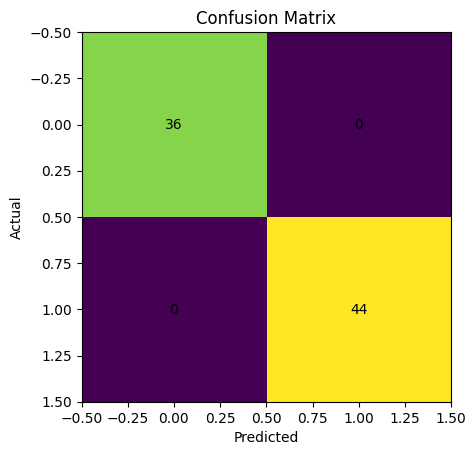

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()